# Parcial - Clasificación de Flores con CNN

En este cuaderno se construye un sistema de visión artificial para clasificar flores usando el dataset **Flower Photos** de TensorFlow.

Flujo general:
1. Descarga y preparación del dataset.
2. Preprocesamiento y partición de datos.
3. Construcción de una red neuronal convolucional (CNN).
4. Entrenamiento, evaluación y visualización de métricas.
5. Prueba con imágenes nuevas y guardado del modelo.

In [18]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("TensorFlow:", tf.__version__)

# Para reproducibilidad
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow: 2.19.0


In [19]:
# Descarga automática del dataset Flower Photos
url = "http://download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file("flower_photos", origin=url, untar=True)
data_dir = pathlib.Path(data_dir)

# En algunos entornos get_file deja una carpeta contenedora adicional
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"

print("Ruta del dataset:", data_dir)
print("Clases detectadas:", [item.name for item in data_dir.iterdir() if item.is_dir()])

Ruta del dataset: /root/.keras/datasets/flower_photos/flower_photos
Clases detectadas: ['roses', 'tulips', 'daisy', 'sunflowers', 'dandelion']


In [20]:
# Preparar dataset en arreglos numpy (estilo Taller 3)
img_height = 64
img_width = 64

# Tomar solo carpetas que realmente tengan imágenes
clases = []
for item in sorted(data_dir.iterdir()):
    if item.is_dir() and len(list(item.glob("*.jpg"))) > 0:
        clases.append(item.name)

print("Clases:", clases)

x_data = []
y_data = []

for idx, clase in enumerate(clases):
    archivos = list((data_dir / clase).glob("*.jpg"))
    for archivo in archivos:
        img = tf.keras.utils.load_img(archivo, target_size=(img_height, img_width))
        img_array = tf.keras.utils.img_to_array(img)
        x_data.append(img_array)
        y_data.append(idx)

x_data = np.array(x_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.int32)

print("Forma de x_data:", x_data.shape)
print("Forma de y_data:", y_data.shape)

# Mezclar datos
indices = np.arange(len(x_data))
np.random.shuffle(indices)
x_data = x_data[indices]
y_data = y_data[indices]

# Dividir: 70% train, 15% val, 15% test
n_total = len(x_data)
n_train = int(0.7 * n_total)
n_val = int(0.85 * n_total)

x_train = x_data[:n_train]
y_train = y_data[:n_train]

x_val = x_data[n_train:n_val]
y_val = y_data[n_train:n_val]

x_test = x_data[n_val:]
y_test = y_data[n_val:]

print("Forma de x_train:", x_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de x_val:", x_val.shape)
print("Forma de y_val:", y_val.shape)
print("Forma de x_test:", x_test.shape)
print("Forma de y_test:", y_test.shape)

Clases: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Forma de x_data: (3670, 64, 64, 3)
Forma de y_data: (3670,)
Forma de x_train: (2569, 64, 64, 3)
Forma de y_train: (2569,)
Forma de x_val: (550, 64, 64, 3)
Forma de y_val: (550,)
Forma de x_test: (551, 64, 64, 3)
Forma de y_test: (551,)


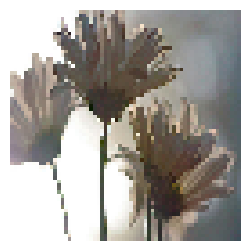

Primera etiqueta (y_train[0]): daisy


In [21]:
# Mostrar la primera imagen de entrenamiento y su etiqueta
if len(x_train) == 0:
    print("No hay imágenes en x_train. Revisa la ruta del dataset o las clases detectadas.")
else:
    plt.figure(figsize=(3, 3))
    plt.imshow(x_train[0].astype("uint8"))
    plt.axis("off")
    plt.show()

    print("Primera etiqueta (y_train[0]):", clases[y_train[0]])

In [22]:
# Normalización (igual al enfoque del Taller 3)
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Verificar cardinalidad de etiquetas
y_train_unique = np.unique(y_train)
print("Valores únicos en y_train:", y_train_unique)
print("Cardinalidad de y_train:", len(y_train_unique))

# One-hot encoding
y_train_categorical = to_categorical(y_train, len(clases))
y_val_categorical = to_categorical(y_val, len(clases))
y_test_categorical = to_categorical(y_test, len(clases))

Valores únicos en y_train: [0 1 2 3 4]
Cardinalidad de y_train: 5


In [23]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

# Construcción de la red convolucional (misma lógica del Taller 3)
input_layer = Input(shape=(img_height, img_width, 3))

conv1 = Conv2D(64, kernel_size=(3, 3), activation="relu")(input_layer)
pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

conv2 = Conv2D(32, kernel_size=(3, 3), activation="relu")(pool1)
pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

flatten = Flatten()(pool2)
dense = Dense(64, activation="relu")(flatten)
output = Dense(len(clases), activation="softmax")(dense)

model = Model(inputs=input_layer, outputs=output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,053 (1.61 MB)

 Trainable params: 422,053 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Compilar y entrenar (igual al Taller 3)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    x_train,
    y_train_categorical,
    epochs=30,
    validation_data=(x_val, y_val_categorical),
    batch_size=32,
)

print("Entrenamiento finalizado.")

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.4508 - loss: 1.2877 - val_accuracy: 0.5564 - val_loss: 1.1080
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5936 - loss: 1.0409 - val_accuracy: 0.5873 - val_loss: 1.0020
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6563 - loss: 0.8927 - val_accuracy: 0.6182 - val_loss: 0.9465
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7143 - loss: 0.7608 - val_accuracy: 0.6055 - val_loss: 0.9671
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7696 - loss: 0.6413 - val_accuracy: 0.5745 - val_loss: 1.0315
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8015 - loss: 0.5643 - val_accuracy: 0.6200 - val_loss: 1.0190
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8435 - loss: 0.4583 - val_accuracy: 0.6000 - val_loss: 1.0964
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8649 - loss: 0.3844 - val_accuracy: 0.6000 - val_los

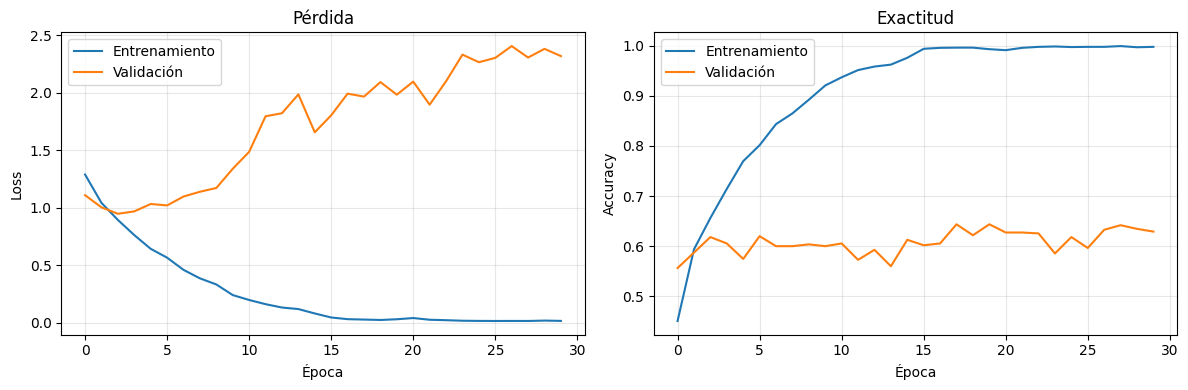

In [25]:
# Curvas de entrenamiento
hist = history.history

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist["loss"], label="Entrenamiento")
ax[0].plot(hist["val_loss"], label="Validación")
ax[0].set_title("Pérdida")
ax[0].set_xlabel("Época")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(hist["accuracy"], label="Entrenamiento")
ax[1].plot(hist["val_accuracy"], label="Validación")
ax[1].set_title("Exactitud")
ax[1].set_xlabel("Época")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


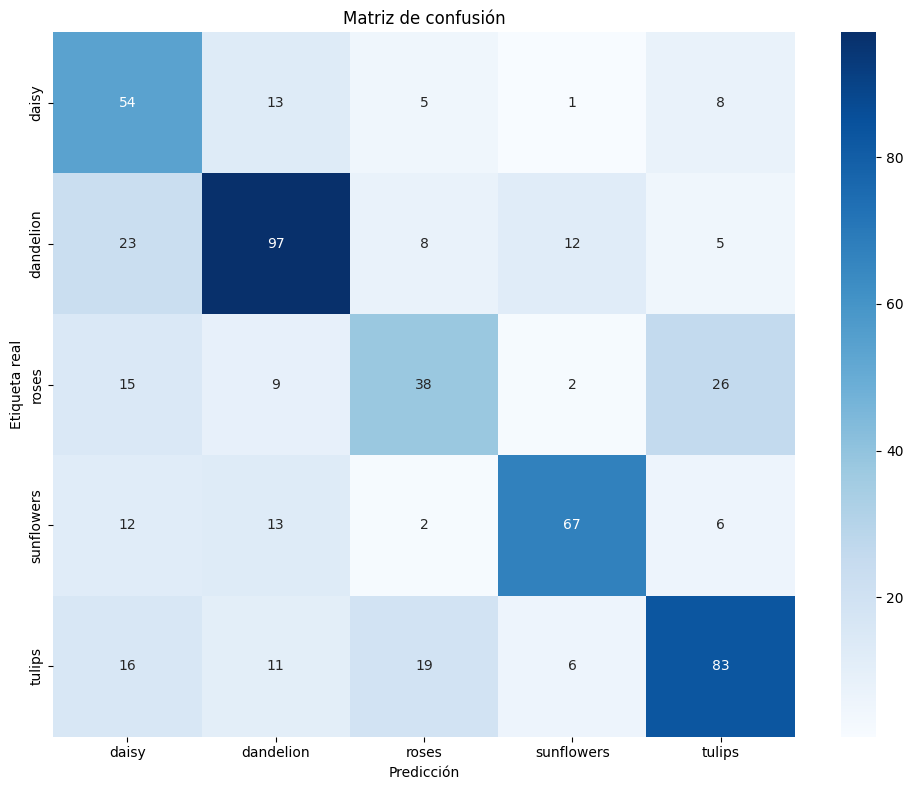

Reporte de clasificación:

              precision    recall  f1-score   support

       daisy       0.45      0.67      0.54        81
   dandelion       0.68      0.67      0.67       145
       roses       0.53      0.42      0.47        90
  sunflowers       0.76      0.67      0.71       100
      tulips       0.65      0.61      0.63       135

    accuracy                           0.62       551
   macro avg       0.61      0.61      0.60       551
weighted avg       0.63      0.62      0.62       551

Accuracy en test: 0.6152


In [26]:
# Evaluación en test (estilo Taller 3)
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases,
)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.show()

# Métricas de clasificación
print("Reporte de clasificación:\n")
print(classification_report(y_true, y_pred, target_names=clases))

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy en test: {acc:.4f}")

Imagen cargada desde URL.
Etiqueta asignada: roses
Probabilidad: 0.9951


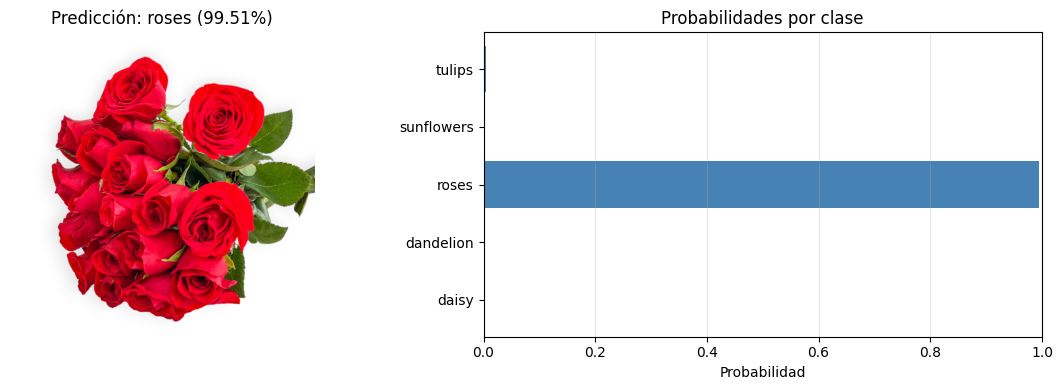

In [28]:
from urllib.request import urlopen, Request
from urllib.error import HTTPError, URLError
from io import BytesIO
from PIL import Image

# URL de la imagen
img_url = "https://flordeliz.com/wp-content/uploads/2024/08/Historia-de-Instagram-Photoroom-2024-08-20T112626.268-1.jpg"

# Cargar imagen desde URL con cabeceras para reducir bloqueos 403
try:
    req = Request(
        img_url,
        headers={
            "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36",
            "Referer": "https://www.google.com/",
        },
    )
    img_bytes = urlopen(req, timeout=20).read()
    img = Image.open(BytesIO(img_bytes)).convert("RGB")
    print("Imagen cargada desde URL.")
except (HTTPError, URLError, TimeoutError) as e:
    print(f"No se pudo descargar la URL ({e}). Se usa una imagen local del dataset.")
    fallback_paths = list(data_dir.glob("*/*.jpg"))
    if len(fallback_paths) == 0:
        raise ValueError("No hay imágenes disponibles ni en URL ni en el dataset local.")
    img = Image.open(fallback_paths[0]).convert("RGB")

# Preprocesar para el modelo entrenado (img_width x img_height, RGB, [0,1])
img_resized = img.resize((img_width, img_height))
img_array = np.array(img_resized, dtype=np.float32) / 255.0
img_batch = np.expand_dims(img_array, axis=0)

# Predicción
probs = model.predict(img_batch, verbose=0)[0]
pred_idx = np.argmax(probs)
pred_label = clases[pred_idx]

print(f"Etiqueta asignada: {pred_label}")
print(f"Probabilidad: {probs[pred_idx]:.4f}")

# Mostrar imagen + probabilidades por clase
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].imshow(img)
ax[0].set_title(f"Predicción: {pred_label} ({probs[pred_idx]*100:.2f}%)")
ax[0].axis("off")

ax[1].barh(clases, probs, color="steelblue")
ax[1].set_xlim(0, 1)
ax[1].set_xlabel("Probabilidad")
ax[1].set_title("Probabilidades por clase")
ax[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Guardar modelo entrenado
model.save("modelo_flores_cnn.keras")
print("Modelo guardado como modelo_flores_cnn.keras")

Modelo guardado como modelo_flores_cnn.keras
